In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
 
gev_depth    = pd.read_csv('../results/design_rainfall_gev.csv',
                            index_col='duration_h').astype(float)
gumbel_depth = pd.read_csv('../results/design_rainfall_gumbel.csv',
                            index_col='duration_h').astype(float)
 
print("GEV design depths (mm):")
print(gev_depth.round(1))
 

GEV design depths (mm):
               2     5    10    20     50    100
duration_h                                      
1           18.6  25.8  31.7  38.3   48.6   57.8
2           21.5  30.7  38.6  47.8   62.5   76.3
3           24.6  34.9  43.1  52.2   65.8   77.8
6           28.4  40.5  51.3  64.2   85.7  106.4
12          33.6  49.6  64.6  83.4  116.6  150.2
24          33.2  48.0  61.0  76.4  101.9  126.1


In [2]:
durations = gev_depth.index.astype(float).values
 
gev_intensity    = gev_depth.divide(durations, axis=0)
gumbel_intensity = gumbel_depth.divide(durations, axis=0)
 
print("GEV intensities (mm/h):")
print(gev_intensity.round(2))
 
gev_intensity.round(3).to_csv('../results/idf_intensity_gev.csv')
gev_depth.round(3).to_csv('../results/ddf_depth_gev.csv')
print("\nSaved: results/idf_intensity_gev.csv")
print("Saved: results/ddf_depth_gev.csv")

GEV intensities (mm/h):
                2      5     10     20     50    100
duration_h                                          
1           18.61  25.80  31.67  38.28  48.56  57.78
2           10.76  15.37  19.30  23.88  31.27  38.15
3            8.19  11.65  14.38  17.38  21.94  25.92
6            4.73   6.76   8.55  10.70  14.29  17.74
12           2.80   4.14   5.38   6.95   9.72  12.52
24           1.38   2.00   2.54   3.18   4.24   5.25

Saved: results/idf_intensity_gev.csv
Saved: results/ddf_depth_gev.csv


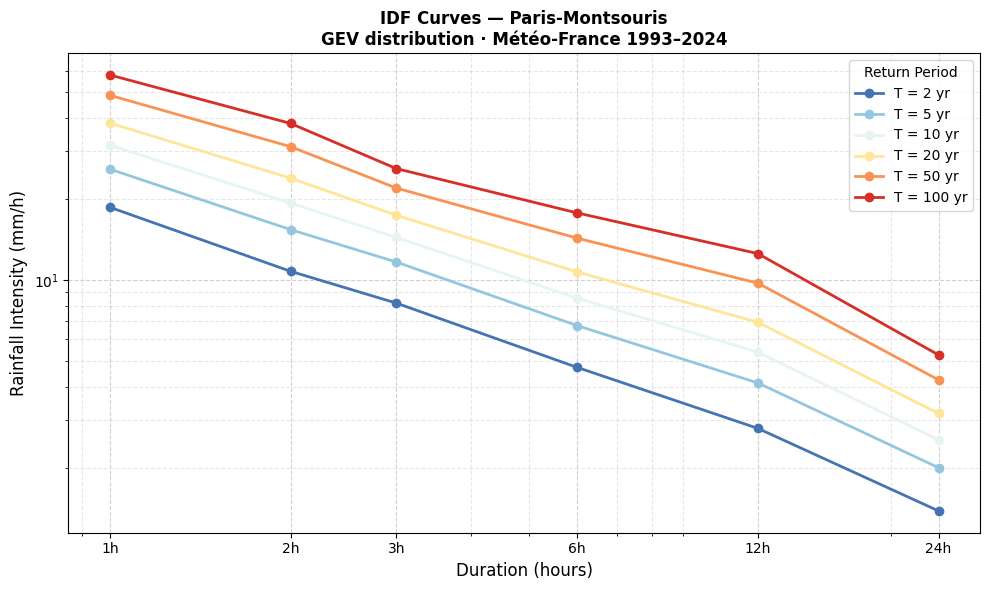

Saved: results/idf_curves.png


In [3]:
return_periods = [int(c) for c in gev_intensity.columns]
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(return_periods)))
 
fig, ax = plt.subplots(figsize=(10, 6))
for i, T in enumerate(return_periods):
    ax.plot(durations, gev_intensity[str(T)].values,
            color=colors[i], marker='o', lw=2, ms=6, label=f'T = {T} yr')
 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(durations)
ax.set_xticklabels([f'{int(d)}h' for d in durations])
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xlabel('Duration (hours)', fontsize=12)
ax.set_ylabel('Rainfall Intensity (mm/h)', fontsize=12)
ax.set_title('IDF Curves — Paris-Montsouris\n'
             'GEV distribution · Météo-France 1993–2024',
             fontsize=12, fontweight='bold')
ax.legend(title='Return Period', fontsize=10)
ax.grid(True, which='both', alpha=0.3, linestyle='--')
ax.grid(True, which='major', alpha=0.6)
plt.tight_layout()
plt.savefig('../results/idf_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/idf_curves.png")

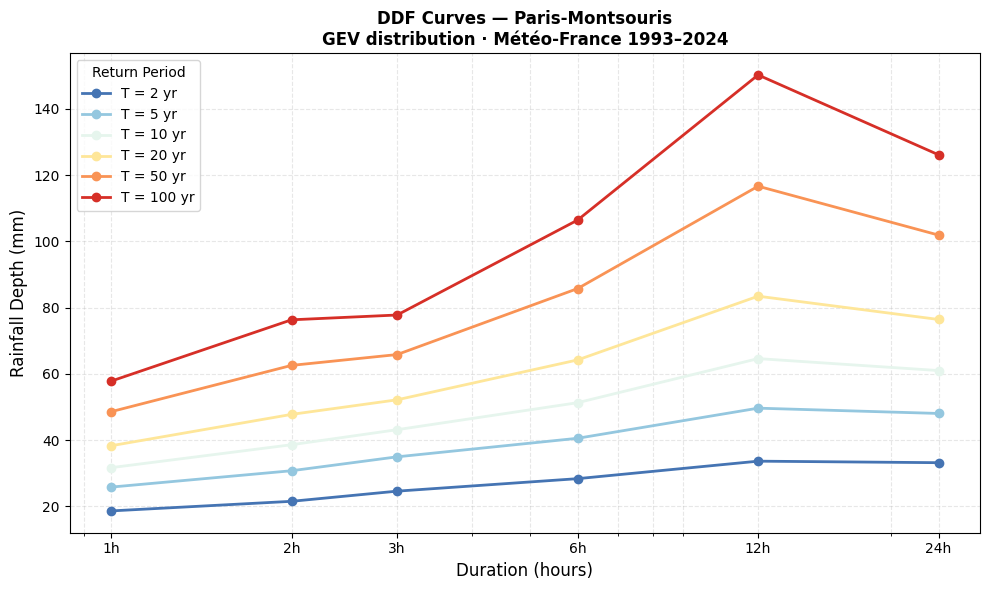

Saved: results/ddf_curves.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, T in enumerate(return_periods):
    ax.plot(durations, gev_depth[str(T)].values,
            color=colors[i], marker='o', lw=2, ms=6, label=f'T = {T} yr')
 
ax.set_xscale('log')
ax.set_xticks(durations)
ax.set_xticklabels([f'{int(d)}h' for d in durations])
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xlabel('Duration (hours)', fontsize=12)
ax.set_ylabel('Rainfall Depth (mm)', fontsize=12)
ax.set_title('DDF Curves — Paris-Montsouris\n'
             'GEV distribution · Météo-France 1993–2024',
             fontsize=12, fontweight='bold')
ax.legend(title='Return Period', fontsize=10)
ax.grid(True, which='both', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../results/ddf_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/ddf_curves.png")

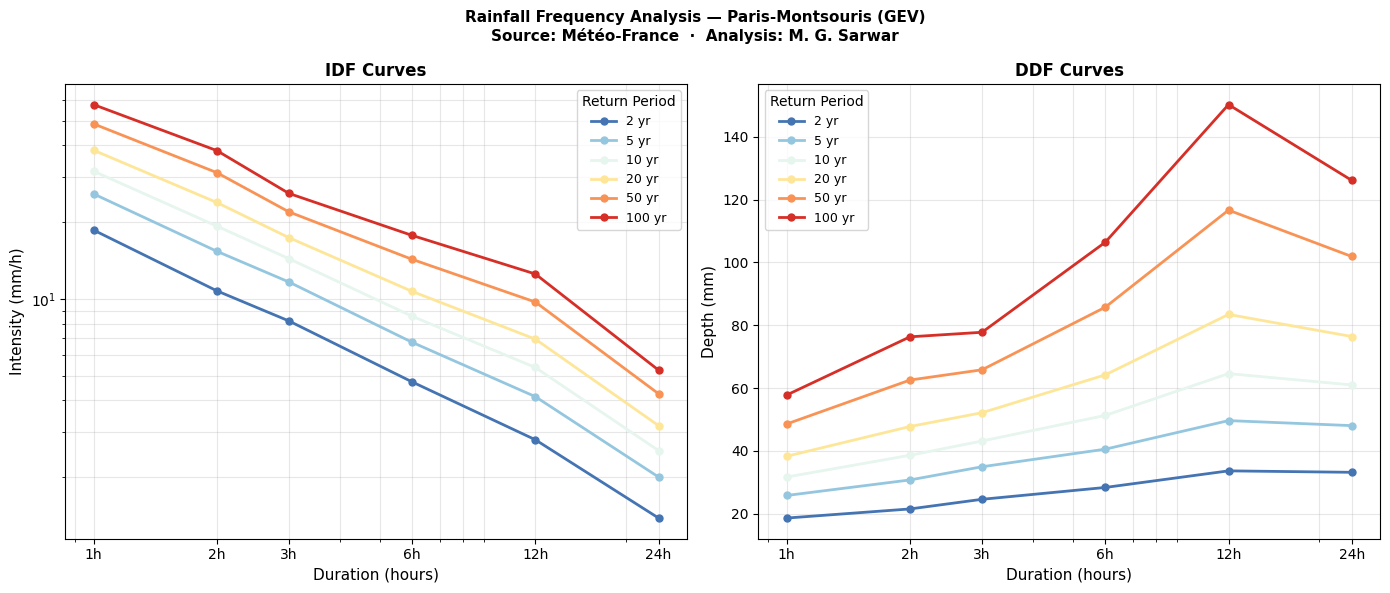

Saved: results/idf_ddf_combined.png

NB04 COMPLETE


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
 
for i, T in enumerate(return_periods):
    kw = dict(color=colors[i], marker='o', lw=2, ms=5, label=f'{T} yr')
    ax1.plot(durations, gev_intensity[str(T)].values, **kw)
    ax2.plot(durations, gev_depth[str(T)].values,    **kw)
 
for ax, ylabel, title in [
    (ax1, 'Intensity (mm/h)', 'IDF Curves'),
    (ax2, 'Depth (mm)',       'DDF Curves'),
]:
    ax.set_xscale('log')
    ax.set_xticks(durations)
    ax.set_xticklabels([f'{int(d)}h' for d in durations])
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel('Duration (hours)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(title='Return Period', fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
 
ax1.set_yscale('log')
 
plt.suptitle('Rainfall Frequency Analysis — Paris-Montsouris (GEV)\n'
             'Source: Météo-France  ·  Analysis: M. G. Sarwar',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/idf_ddf_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/idf_ddf_combined.png")
print("\nNB04 COMPLETE")